In [1]:
import pandas as pd
import numpy as np
import pyarrow
from sklearn.model_selection import  train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers
import keras
import tensorflow as tf

# Configurações 
print(tf.config.list_physical_devices())
BATCH_SIZE = 1024

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Função para encontrar o número máximo de neurônio**

In [2]:
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

## **Leitura dos dados e adaptações necessárias para a rede neural**

In [3]:
df = pd.read_parquet('data/Acertos_ParametrosTRI_Nota')

In [4]:
# Exiba todas as colunas do DataFrame uma por uma num for loop
df.columns.tolist()

['NU_ANO',
 'TP_FAIXA_ETARIA',
 'TP_ESTADO_CIVIL',
 'TP_ST_CONCLUSAO',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT',
 'NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'TP_LINGUA',
 'TP_STATUS_REDACAO',
 'NU_NOTA_REDACAO',
 'Q001',
 'Q002',
 'Q003',
 'Q004',
 'Q005',
 'Q006',
 'Q007',
 'Q008',
 'Q009',
 'Q010',
 'Q011',
 'Q012',
 'Q013',
 'Q014',
 'Q015',
 'Q016',
 'Q017',
 'Q018',
 'Q019',
 'Q020',
 'Q021',
 'Q022',
 'Q023',
 'Q024',
 'Q025',
 'NU_PARAM_A_Q_LC_01',
 'NU_PARAM_A_Q_LC_02',
 'NU_PARAM_A_Q_LC_03',
 'NU_PARAM_A_Q_LC_04',
 'NU_PARAM_A_Q_LC_05',
 'NU_PARAM_A_Q_LC_06',
 'NU_PARAM_A_Q_LC_07',
 'NU_PARAM_A_Q_LC_08',
 'NU_PARAM_A_Q_LC_09',
 'NU_PARAM_A_Q_LC_10',
 'NU_PARAM_A_Q_LC_11',
 'NU_PARAM_A_Q_LC_12',
 'NU_PARAM_A_Q_LC_13',
 'NU_PARAM_A_Q_LC_14',
 'NU_PARAM_A_Q_LC_15',
 'NU_PARAM_A_Q_LC_16',
 'NU_PARAM_A_Q_LC_17',
 'NU_PARAM_A_Q_LC_

In [5]:
df['TOTAL_ACERTOS_GERAL'] = df['TOTAL_ACERTOS_LC'] + df['TOTAL_ACERTOS_CH'] + df['TOTAL_ACERTOS_CN'] + df['TOTAL_ACERTOS_MT']

df['CLASSE'] = df.groupby('NU_ANO')['TOTAL_ACERTOS_GERAL'].transform(lambda x: pd.qcut(x, q=3, labels=[0, 1, 2])).astype('Int64')
    
df= df.dropna(subset=['CLASSE'])

df['CLASSE'] = df['CLASSE'].astype(int)

In [9]:
df_reduzido = df.sample(n=100_000, random_state=42)
    
features = (
        [f'ACERTO_LC_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CH_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CN_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_MT_{i:02d}' for i in range(1, 46)] +
        ['TOTAL_ACERTOS_LC', 'TOTAL_ACERTOS_CH', 'TOTAL_ACERTOS_CN', 'TOTAL_ACERTOS_MT']
    )

df_reduzido.fillna(-1, inplace=True)
X = df_reduzido[features]
y = df_reduzido['CLASSE']


## **Separando os dados**

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## **Normalizando os dados**

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train).astype(np.float32)
x_val   = scaler.transform(x_val).astype(np.float32)
x_test  = scaler.transform(x_test).astype(np.float32)

In [12]:
# Analisando os dados do rotulo de treinamento
print("Tipo:", y_train.dtype)
print("Valores únicos:", np.unique(y_train))
print("Amostra:", y_train[:10])

Tipo: int64
Valores únicos: [0 1 2]
Amostra: 1713323    2
414829     0
1030149    0
1909991    2
1630004    0
1803135    1
935843     1
1673106    1
2013017    2
201947     2
Name: CLASSE, dtype: int64


## **Construindo a rede neural**

In [13]:
max_neurons = num_max_neuronio(x_train, d = 1)
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 2133


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

model = Sequential()
model.add(Dense(100, input_dim=184,
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.0001),
                activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(100, kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(0.0001),
                activation='relu'))
model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(3, kernel_initializer='he_normal', activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', patience=10, verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/5


/Users/sergioo/Documents/GitHub/Projeto_ENEM/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-23 19:17:14.513887: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-23 19:17:14.514066: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-23 19:17:14.514096: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-23 19:17:14.514128: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-23 19:17:14.514154: I tensorflow/core/common_runtime/pluggable_device/pluggable_devic

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6273 - loss: 0.9278 - val_accuracy: 0.8606 - val_loss: 0.5533
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8252 - loss: 0.6003 - val_accuracy: 0.9070 - val_loss: 0.5481
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8544 - loss: 0.5858 - val_accuracy: 0.9183 - val_loss: 0.5424
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8634 - loss: 0.5930 - val_accuracy: 0.9246 - val_loss: 0.5744
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8698 - loss: 0.5988 - val_accuracy: 0.8781 - val_loss: 0.6073


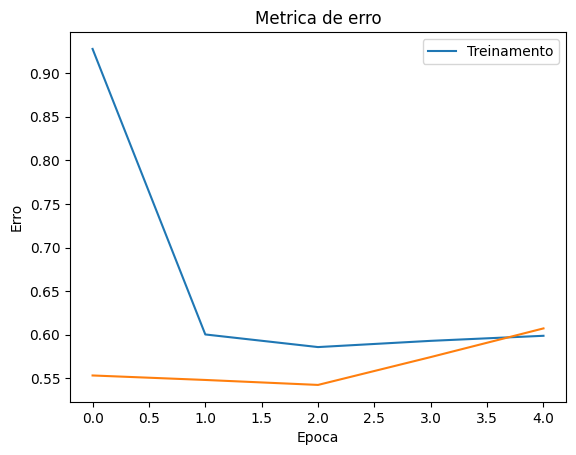

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8781 - loss: 0.6073

--> Acuracia (treino): 0.8814
--> Acuracia (validacao): 0.8781
--> E_val - E_in = 0.0083
--> acc_train - acc_val = 0.0034


In [15]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(x_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validação
E_val, acc_val = model.evaluate(x_val, y_val, batch_size=BATCH_SIZE)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")